# Introduction
The goal of this project is to perform **face detection** by locating the **eye area** using the **Integral Image technique**.

We will:
1. Compute the Integral Image of a given face image.
2. Use it to calculate local pixel sums efficiently.
3. Convolve a kernel to detect the eye area.
4. Extract and display the detected eye region.

This notebook includes four main functions:
- `CalculateIntegral()`
- `CalculateLocalSum()`
- `DetectEye()`
- `ExtractDetectedEye()`

### Load the Image

Convert image to grayscale (since we only need intensity)



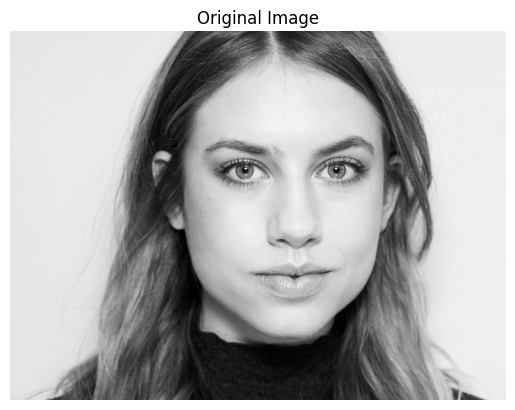

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load grayscale image
image_path = 'Image 1.jpeg'  
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) ## convert to array

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

### CalculateIntegral

**Input:**  
- 2D array representing the image

**Output:**  
- 2D array representing the integral image

**Description:**  
For each pixel (x, y):
`ii(x, y) = image(x, y) + ii(x-1, y) + ii(x, y-1) - ii(x-1, y-1)`

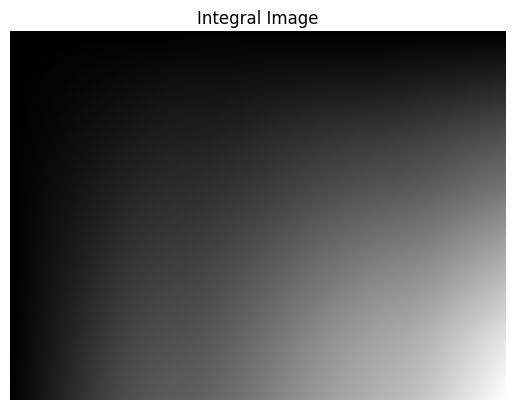

In [2]:
def CalculateIntegral(image):
    h, w = image.shape
    ii = np.zeros((h, w), dtype=np.float64)

    for y in range(h):
        for x in range(w):
            ii[y, x] = image[y, x]
            if x > 0:
                ii[y, x] += ii[y, x-1]
            if y > 0:
                ii[y, x] += ii[y-1, x]
            if x > 0 and y > 0:
                ii[y, x] -= ii[y-1, x-1]
    return ii

# Test it
integral_img = CalculateIntegral(image)
plt.imshow(integral_img, cmap='gray')
plt.title('Integral Image')
plt.axis('off')
plt.show()

### CalculateLocalSum

**Input:**  
- An integral image (2D array)
- Two pairs of coordinates: (x0, y0) (upper left), (x1, y1) (lower right)

**Output:**  
- The local sum for the rectangular area defined by the pair of points

**Description:**  
This function calculates the local sum for any rectangular area using the integral image. It should not contain any loops.

In [3]:
def CalculateLocalSum(ii, p0, p1):
    x0, y0 = p0
    x1, y1 = p1

    total = ii[y1, x1]
    if x0 > 0:
        total -= ii[y1, x0 - 1]
    if y0 > 0:
        total -= ii[y0 - 1, x1]
    if x0 > 0 and y0 > 0:
        total += ii[y0 - 1, x0 - 1]
    return total

# Example test
sum_test = CalculateLocalSum(integral_img, (10,10), (50,50))
print(sum_test)

387388.0


### Define the Kernel (Eye Detector)

The kernel is made of several rectangles, each with a specific weight.

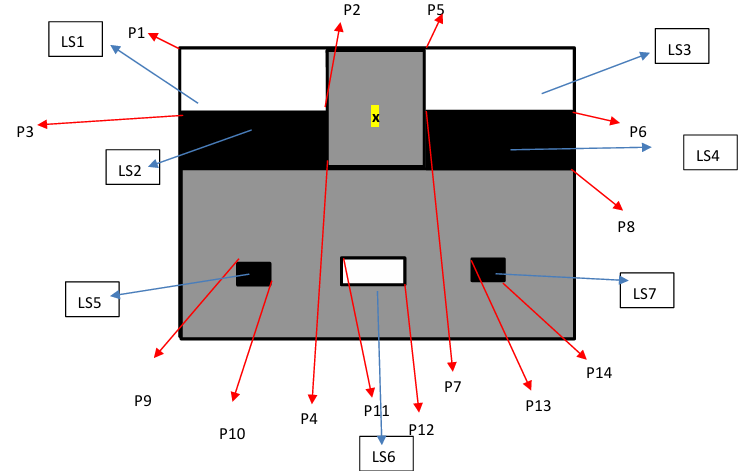
| Rectangle | Relative Position           | Weight | Color  |
|-----------|-----------------------------|--------|--------|
| LS1       | Upper-left                  | +1     | White  |
| LS2       | Upper-middle (between eyes) | –1     | Black  |
| LS3       | Upper-right                 | +1     | White  |
| LS4       | Lower-left                  | –1     | Black  |
| LS5       | Lower-middle                | –1     | Black  |
| LS6       | Lower-center (between eyes) | +2     | White  |
| LS7       | Lower-right                 | –1     | Black  |


*Assign regions and boundaries based on P1–P14 as shown in the assignment image. 
Weights strictly follow the assignment instructions for color: white = +1, black = –1, gray = 0 (neglected).*


###  Given Position i and j in the integral image Calculate the 14 points of the kernel

In [4]:
def _CalculateKernelPoints(center_j, center_i, n, m):
    points = {}
    
    points['p1'] = (center_j - int(0.5*n), center_i - int(0.5*m))
    points['p2'] = (center_j - int(0.05*n), center_i)
    points['p3'] = (center_j - int(0.5*n), center_i)
    points['p4'] = (center_j - int(0.05*n), center_i + int(0.5*m))
    points['p5'] = (center_j + int(0.05*n), center_i - int(0.5*m))
    points['p6'] = (center_j + int(0.5*n), center_i)
    points['p7'] = (center_j + int(0.05*n), center_i)
    points['p8'] = (center_j + int(0.5*n), center_i + int(0.5*m))
    points['p9'] = (center_j - int(0.325*n), center_i + int(0.833*m))
    points['p10'] = (center_j - int(0.225*n), center_i + 2*m)
    points['p11'] = (center_j - int(0.1*n), center_i + int(0.833*m))
    points['p12'] = (center_j + int(0.1*n), center_i + 2*m)
    points['p13'] = (center_j + int(0.225*n), center_i + int(0.833*m))
    points['p14'] = (center_j + int(0.325*n), center_i + 2*m)
    
    return points

### Calculate the Score of given kernal position:

- Compute local sums for each rectangle using the integral image.
- Multiply each by its weight.
- return result`.

In [5]:
def _CalculateKernelScore(integral_image, points):
    p1 = points['p1']   # (-0.5n, -0.5m)
    p2 = points['p2']   # (-0.05n, 0)
    p3 = points['p3']   # (-0.5n, 0)
    p4 = points['p4']   # (-0.05n, +0.5m)
    p5 = points['p5']   # (+0.05n, -0.5m)
    p6 = points['p6']   # (+0.5n, 0)
    p7 = points['p7']   # (+0.05n, 0)
    p8 = points['p8']   # (+0.5n, +0.5m)
    p9 = points['p9']   # (-0.325n, +0.833m)
    p10 = points['p10'] # (-0.225n, +2m)
    p11 = points['p11'] # (-0.1n, +0.833m)
    p12 = points['p12'] # (+0.1n, +2m)
    p13 = points['p13'] # (+0.225n, +0.833m)
    p14 = points['p14'] # (+0.325n, +2m)
    
    # LS1: Rectangle from P1 to (P2)
    ls1 = CalculateLocalSum(integral_image, p1, (p2[0]-1, p2[1]-1))
    
    # LS2: Rectangle from P3 to P4
    ls2 = CalculateLocalSum(integral_image, p3, (p4[0]-1, p4[1]-1))
    
    # LS3: Rectangle from P5 to (P6)
    ls3 = CalculateLocalSum(integral_image, p5, (p6[0]-1, p6[1]-1))
    
    # LS4: Rectangle from P7 to P8
    ls4 = CalculateLocalSum(integral_image, p7, (p8[0]-1, p8[1]-1))
    
    # LS5: Small black rectangle (bottom-left)
    ls5 = CalculateLocalSum(integral_image, p9, (p10[0]-1, p10[1]-1))
    
    # LS6: Small white rectangle (bottom-middle)
    ls6 = CalculateLocalSum(integral_image, p11, (p12[0]-1, p12[1]-1))
    
    # LS7: Small black rectangle (bottom-right)
    ls7 = CalculateLocalSum(integral_image, p13, (p14[0]-1, p14[1]-1))
    
    score = ls1 - ls2 + ls3 - ls4 - ls5 + (2*ls6) - ls7
    
    return score

### DetectEye

**Input:**  
- The integral image (2D array)
- Kernel width (n)

**Output:**  
- Coordinates (i, j) representing the position of the maximum score from kernel convolution

**Description:**  
Finds the region with the highest score corresponding to the eye area, by convolving the kernel across the face image. Kernel height is calculated as m = 0.15n. The kernel should use the structure provided in the assignment.

In [6]:
def DetectEye(integral_image, kernel_width):
    n = kernel_width
    m = int(0.15 * n)  # kernel height
    
    rows, cols = integral_image.shape
    max_score = -np.inf
    max_position = (0, 0)
    
    # Slide kernel across image
    for i in range(rows - 2*m):
        for j in range(int(n/2), cols - int(n/2)):
            
            # Step 1: Calculate the 14 kernel points at this position
            points = _CalculateKernelPoints(j, i, n, m)
            
            # Check boundaries
            p1 = points['p1']
            p10 = points['p10']
            p14 = points['p14']
            
            if (p1[0] < 0 or p1[1] < 0 or p10[0] < 0 or p10[1] >= rows or 
                p14[0] >= cols or p14[1] >= rows):
                continue
            
            # Step 2: Calculate kernel score at this position
            score = _CalculateKernelScore(integral_image, points)
            
            # Step 3: Track maximum score
            if score > max_score:
                max_score = score
                max_position = (i, j)
    
    return max_position

### for test only

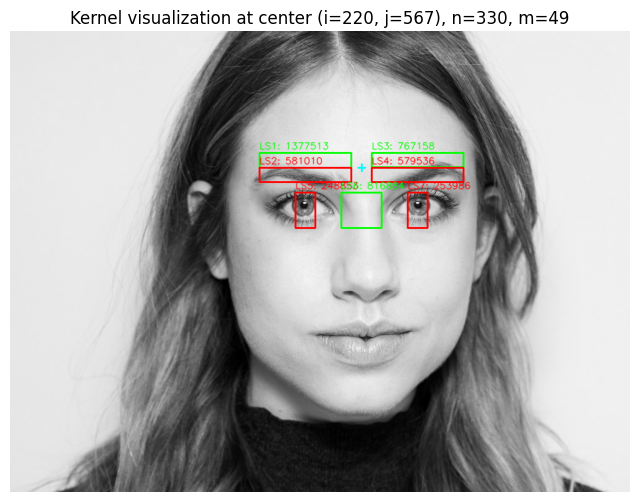

In [7]:
def _clamp_rect(x0, y0, x1, y1, w, h):
    x0 = max(0, min(w-1, x0)); x1 = max(0, min(w-1, x1))
    y0 = max(0, min(h-1, y0)); y1 = max(0, min(h-1, y1))
    if x1 < x0: x0, x1 = x1, x0
    if y1 < y0: y0, y1 = y1, y0
    return x0, y0, x1, y1

def visualize_kernel_sums(image_gray, integral_img, center_pos, n):
    # center_pos is (i, j) as returned by DetectEye
    ci, cj = center_pos
    m = int(0.15 * n)
    h, w = image_gray.shape

    points = _CalculateKernelPoints(cj, ci, n, m)

    # Create color image for drawing
    vis = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2BGR)

    # Define rectangles exactly as used in _CalculateKernelScore
    rects = []
    # LS1: p1 -> (p2.x-1, p4.y-1)
    rects.append(("LS1", points['p1'], (points['p2'][0]-1, points['p4'][1]-1), (0,255,0)))
    # LS2: p3 -> p4
    rects.append(("LS2", points['p3'], (points['p4'][0]-1, points['p4'][1]-1), (0,0,255)))
    # LS3: p5 -> (p6.x-1, p6.y-1)
    rects.append(("LS3", points['p5'], (points['p6'][0]-1, points['p6'][1]-1), (0,255,0)))
    # LS4: p7 -> (p8.x-1, p8.y-1)
    rects.append(("LS4", points['p7'], (points['p8'][0]-1, points['p8'][1]-1), (0,0,255)))
    # LS5: p9 -> (p10.x-1, p10.y-1)
    rects.append(("LS5", points['p9'], (points['p10'][0]-1, points['p10'][1]-1), (0,0,255)))
    # LS6: p11 -> (p12.x-1, p12.y-1)
    rects.append(("LS6", points['p11'], (points['p12'][0]-1, points['p12'][1]-1), (0,255,0)))
    # LS7: p13 -> (p14.x-1, p14.y-1)
    rects.append(("LS7", points['p13'], (points['p14'][0]-1, points['p14'][1]-1), (0,0,255)))

    # Draw and annotate
    for name, p0, p1, color in rects:
        x0, y0 = p0; x1, y1 = p1
        x0, y0, x1, y1 = _clamp_rect(x0, y0, x1, y1, w, h)
        if x1 <= x0 or y1 <= y0:
            continue
        # Calculate local sum using same function (coordinates are (x,y))
        s = CalculateLocalSum(integral_img, (x0, y0), (x1, y1))
        # Draw rectangle (BGR)
        cv2.rectangle(vis, (x0, y0), (x1, y1), color, 2)
        # Put label and sum
        label = f"{name}: {int(s)}"
        text_pos = (x0, max(0, y0-6))
        cv2.putText(vis, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    # Mark kernel center
    cv2.drawMarker(vis, (cj, ci), (255,255,0), markerType=cv2.MARKER_CROSS, markerSize=12, thickness=2)
    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Kernel visualization at center (i={ci}, j={cj}), n={n}, m={m}")
    plt.show()
    
eye_position = DetectEye(integral_img, kernel_width=330)
visualize_kernel_sums(image, integral_img, eye_position, n=330)

### ExtractDetectedEye

**Input:**  
- The original image (2D array)
- Position of detected maximum score (i, j)
- Kernel width (n)

**Output:**  
- A 2D array representing the image area containing the detected eye region

**Description:**  
Draws around the detected maximum position using the kernel size, retrieves and returns the pixel region corresponding to the eyes.

In [8]:
def ExtractDetectedEye(image, eye_pos, kernel_size):
    i, j = eye_pos           # i=row, j=col
    n = kernel_size
    m = int(0.15 * n)

    # Calculate kernel points exactly as DetectEye does
    points = _CalculateKernelPoints(j, i, n, m)

    # Compute tight bounding box from all kernel points
    xs = [int(p[0]) for p in points.values()]
    ys = [int(p[1]) for p in points.values()]
    x0, x1 = min(xs), max(xs)
    y0, y1 = min(ys), max(ys)

    # Clamp to image bounds and make inclusive range
    h, w = image.shape
    x0 = max(0, x0)
    y0 = max(0, y0)
    x1 = min(w - 1, x1)
    y1 = min(h - 1, y1)

    # Create masked image and copy kernel region
    masked_image = np.zeros_like(image)
    if x1 >= x0 and y1 >= y0:
        masked_image[y0:y1+1, x0:x1+1] = image[y0:y1+1, x0:x1+1]

    return masked_image

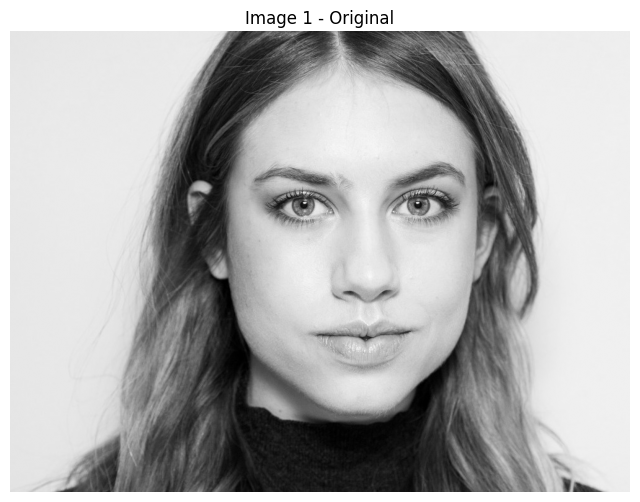

Eye detected at position: (220, 567)


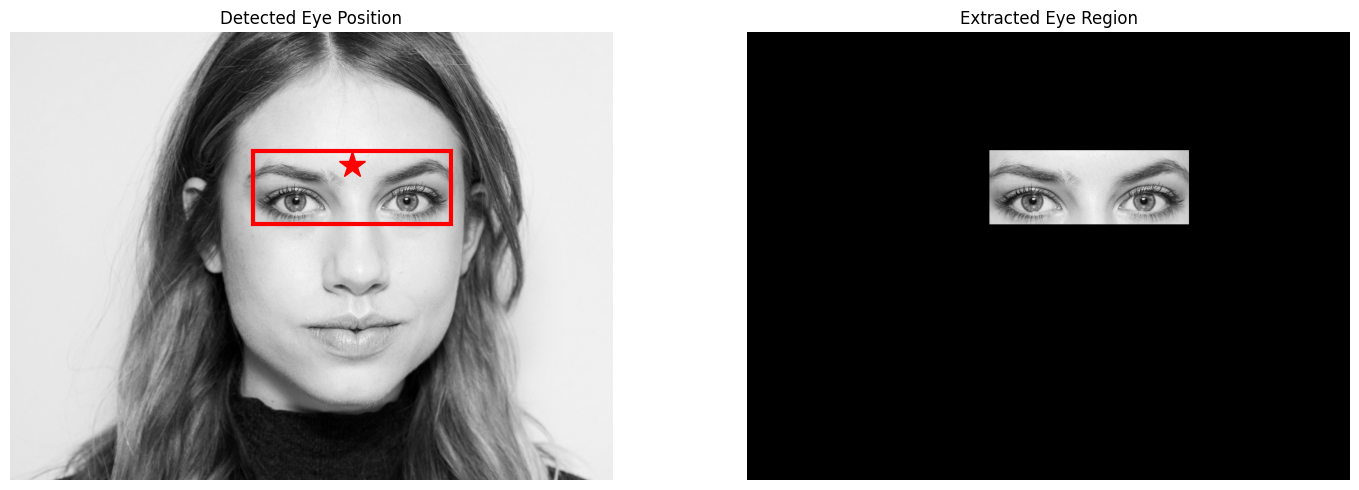

In [9]:
# Load Image 1
image1 = cv2.imread('Image 1.jpeg', cv2.IMREAD_GRAYSCALE)

# Display original
plt.figure(figsize=(8, 6))
plt.imshow(image1, cmap='gray')
plt.title('Image 1 - Original')
plt.axis('off')
plt.show()

# Process
kernel_size_1 = 330
integral1 = CalculateIntegral(image1)
eye_pos_1 = DetectEye(integral1, kernel_size_1)

eye_region_1 = ExtractDetectedEye(image1, eye_pos_1, kernel_size_1)

print(f"Eye detected at position: {eye_pos_1}")

# Display result
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Show detection on original image
axes[0].imshow(image1, cmap='gray')
i, j = eye_pos_1
n = kernel_size_1
m = int(0.15 * n)
rect = plt.Rectangle((j - int(0.5*n), i - int(0.5*m)), n, int(2.5*m), 
                     fill=False, edgecolor='red', linewidth=3)
axes[0].add_patch(rect)
axes[0].plot(j, i, 'r*', markersize=20)
axes[0].set_title('Detected Eye Position')
axes[0].axis('off')

# Show extracted region (full image with masked area)
axes[1].imshow(eye_region_1, cmap='gray')
axes[1].set_title('Extracted Eye Region')
axes[1].axis('off')

plt.tight_layout()
plt.show()

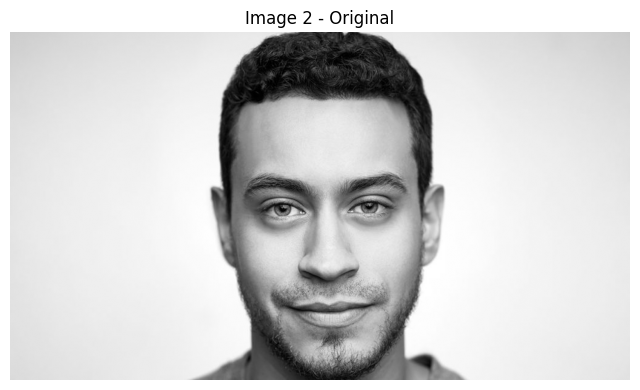

Eye detected at position: (242, 528)


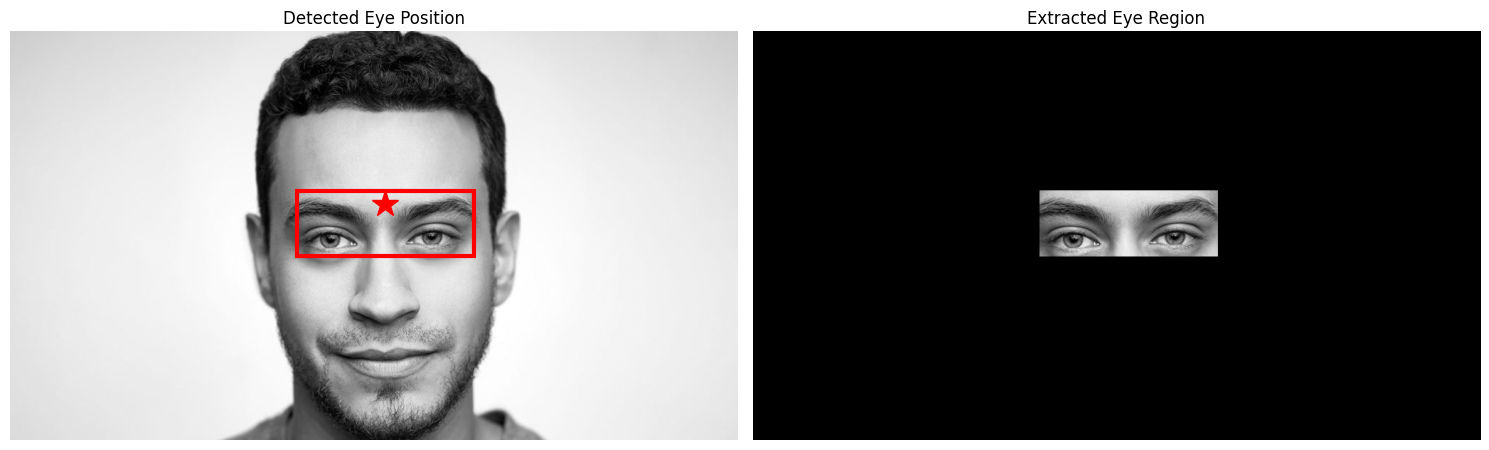

In [10]:
# Load Image 2
image1 = cv2.imread('Image 2.jpeg', cv2.IMREAD_GRAYSCALE)

# Display original
plt.figure(figsize=(8, 6))
plt.imshow(image1, cmap='gray')
plt.title('Image 2 - Original')
plt.axis('off')
plt.show()

# Process
kernel_size_1 = 250
integral1 = CalculateIntegral(image1)
eye_pos_1 = DetectEye(integral1, kernel_size_1)

eye_region_1 = ExtractDetectedEye(image1, eye_pos_1, kernel_size_1)

print(f"Eye detected at position: {eye_pos_1}")

# Display result
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Show detection on original image
axes[0].imshow(image1, cmap='gray')
i, j = eye_pos_1
n = kernel_size_1
m = int(0.15 * n)
rect = plt.Rectangle((j - int(0.5*n), i - int(0.5*m)), n, int(2.5*m), 
                     fill=False, edgecolor='red', linewidth=3)
axes[0].add_patch(rect)
axes[0].plot(j, i, 'r*', markersize=20)
axes[0].set_title('Detected Eye Position')
axes[0].axis('off')

# Show extracted region (full image with masked area)
axes[1].imshow(eye_region_1, cmap='gray')
axes[1].set_title('Extracted Eye Region')
axes[1].axis('off')

plt.tight_layout()
plt.show()

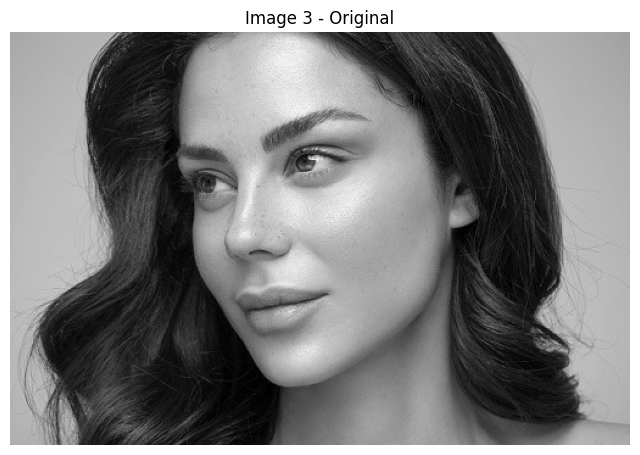

Eye detected at position: (91, 202)


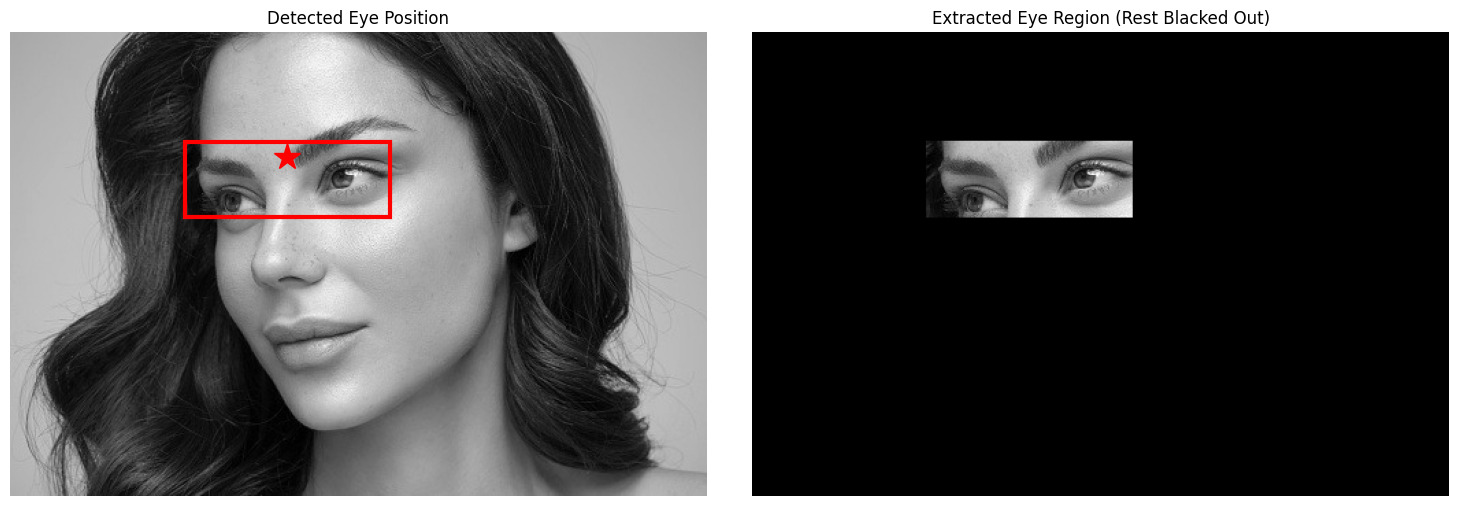

In [11]:
# Load Image 3
image1 = cv2.imread('Image 3.jpeg', cv2.IMREAD_GRAYSCALE)

# Display original
plt.figure(figsize=(8, 6))
plt.imshow(image1, cmap='gray')
plt.title('Image 3 - Original')
plt.axis('off')
plt.show()

# Process
kernel_size_1 = 150
integral1 = CalculateIntegral(image1)
eye_pos_1 = DetectEye(integral1, kernel_size_1)

eye_region_1 = ExtractDetectedEye(image1, eye_pos_1, kernel_size_1)

print(f"Eye detected at position: {eye_pos_1}")

# Display result
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Show detection on original image
axes[0].imshow(image1, cmap='gray')
i, j = eye_pos_1
n = kernel_size_1
m = int(0.15 * n)
rect = plt.Rectangle((j - int(0.5*n), i - int(0.5*m)), n, int(2.5*m), 
                     fill=False, edgecolor='red', linewidth=3)
axes[0].add_patch(rect)
axes[0].plot(j, i, 'r*', markersize=20)
axes[0].set_title('Detected Eye Position')
axes[0].axis('off')

# Show extracted region (full image with masked area)
axes[1].imshow(eye_region_1, cmap='gray')
axes[1].set_title('Extracted Eye Region (Rest Blacked Out)')
axes[1].axis('off')

plt.tight_layout()
plt.show()